# MLG382 Guided Project 2026
## Data Understanding & Preparation

**Dataset:** Diabetes_and_LifeStyle_Dataset_.csv

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# ====================== LOAD DATA ======================
df = pd.read_parquet('../dashboard/data/Diabetes_and_Lifestyle_Dataset_.parquet')

print(" Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

 Dataset loaded successfully!
Shape: 10 rows × 23 columns


,Name,Gender,Age,Height,Weight,BMI,BP,Cholesterol,Triglycerides,HDL,...,Sleep_Hours,Stress_Level,Smoking,Alcohol,Glucose_Fasting,Glucose_Postprandial,HbA1c,Insulin_Level,Diabetes_Stage,Diabetes_Risk_Score
0,Male,0,25,165,60,22.0,120/80,180,150,50,...,8.0,Low,0,0,90,120,5.0,10,0,0.10
1,Female,1,45,160,75,29.3,140/90,220,200,40,...,6.0,High,1,1,110,160,6.5,20,1,0.30
2,Male,0,60,170,90,31.1,150/95,250,250,35,...,7.0,Medium,0,0,130,180,7.2,30,2,0.60
3,Female,1,35,155,55,22.9,125/82,190,160,55,...,7.5,Low,0,0,95,130,5.2,12,0,0.15
4,Male,0,55,175,95,31.0,155/100,240,220,38,...,5.0,High,1,1,140,200,8.0,40,3,0.80


## 1. Data Description (CRISP-DM Data Understanding)

In [3]:
print("=== Columns and Data Types ===")
print(df.dtypes)

print("\n=== Target Variable: Diabetes_Stage ===")
print(df['Diabetes_Stage'].value_counts(dropna=False))
print("\nPercentage:")
print(df['Diabetes_Stage'].value_counts(normalize=True).round(3)*100)

# Duplicate check
print("\n=== Duplicate Records Check ===")
print(f"Total rows before: {len(df):,}")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed! New shape: {df.shape[0]:,} rows")
else:
    print("No duplicate records found.")

=== Columns and Data Types ===
Name                        str
Gender                    int64
Age                       int64
Height                    int64
Weight                    int64
BMI                     float64
BP                          str
Cholesterol               int64
Triglycerides             int64
HDL                       int64
Family_Hist               int64
Physical_Activity           str
Diet_Quality                str
Sleep_Hours             float64
Stress_Level                str
Smoking                   int64
Alcohol                   int64
Glucose_Fasting           int64
Glucose_Postprandial      int64
HbA1c                   float64
Insulin_Level             int64
Diabetes_Stage            int64
Diabetes_Risk_Score     float64
dtype: object

=== Target Variable: Diabetes_Stage ===
Diabetes_Stage
0    4
1    3
3    2
2    1
Name: count, dtype: int64

Percentage:
Diabetes_Stage
0    40.0
1    30.0
3    20.0
2    10.0
Name: proportion, dtype: float64

=== Dup

=== Missing Values ===
✅ No missing values found in the entire dataset!


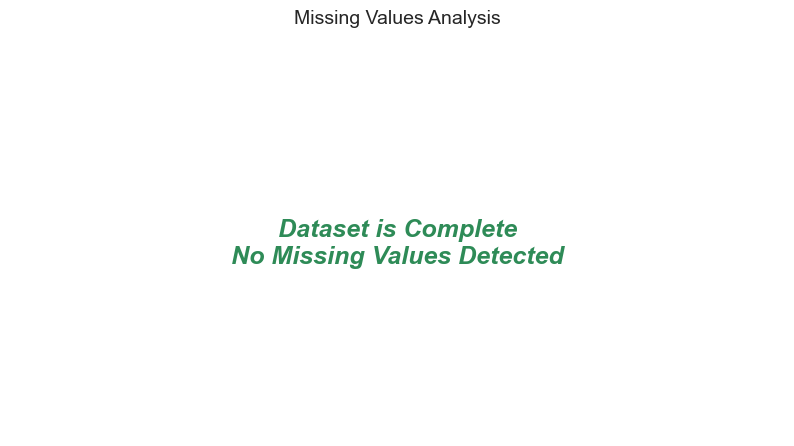

In [4]:
print("=== Missing Values ===")
missing = df.isnull().sum()

if missing.sum() == 0:
    print("✅ No missing values found in the entire dataset!")
    plt.figure(figsize=(10, 5))
    plt.text(0.5, 0.5, 'Dataset is Complete\nNo Missing Values Detected', 
             horizontalalignment='center', verticalalignment='center',
             fontsize=18, color='#2E8B57', weight='bold', style='italic')
    plt.axis('off')
    plt.title('Missing Values Analysis', fontsize=14, pad=20)
    plt.show()
else:
    print(missing[missing > 0])
    plt.figure(figsize=(14, 8))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## 2. Exploratory Data Analysis (EDA)

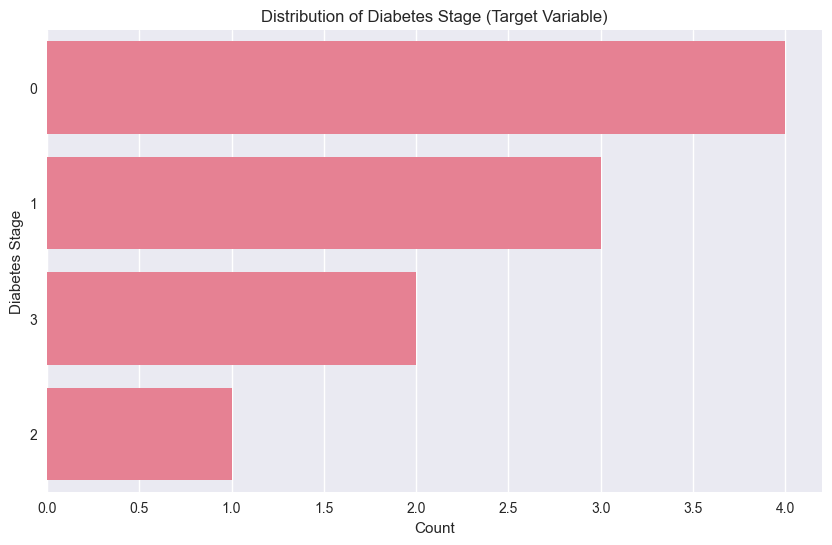

In [5]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Diabetes_Stage', order=df['Diabetes_Stage'].value_counts().index)
plt.title('Distribution of Diabetes Stage (Target Variable)')
plt.xlabel('Count')
plt.ylabel('Diabetes Stage')
plt.show()

In [6]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("=== Numerical Features Summary ===")
display(df[num_cols].describe().round(2))

=== Numerical Features Summary ===


,Gender,Age,Height,Weight,BMI,Cholesterol,Triglycerides,HDL,Family_Hist,Sleep_Hours,Smoking,Alcohol,Glucose_Fasting,Glucose_Postprandial,HbA1c,Insulin_Level,Diabetes_Stage,Diabetes_Risk_Score
count,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00
mean,0.50,43.30,164.90,75.00,27.34,214.70,194.30,44.70,0.60,7.00,0.40,0.40,113.50,158.30,6.35,22.40,1.10,0.38
std,0.53,13.98,6.38,16.53,4.43,29.79,41.10,8.78,0.52,1.29,0.52,0.52,22.26,33.68,1.30,12.75,1.20,0.30
min,0.00,25.00,155.00,55.00,21.60,180.00,148.00,32.00,0.00,5.00,0.00,0.00,88.00,118.00,4.90,9.00,0.00,0.08
25%,0.00,31.25,160.50,60.50,23.08,186.25,156.25,38.50,0.00,6.12,0.00,0.00,92.75,126.25,5.12,11.25,0.00,0.13
50%,0.50,42.50,164.50,72.50,28.65,215.00,195.00,43.50,1.00,7.00,0.00,0.00,112.50,162.50,6.40,21.00,1.00,0.32
75%,1.00,53.75,169.50,88.75,30.78,237.50,217.50,51.50,1.00,7.88,1.00,1.00,128.75,178.75,7.10,28.75,1.75,0.56
max,1.00,65.00,175.00,100.00,33.80,260.00,260.00,58.00,1.00,9.00,1.00,1.00,150.00,210.00,8.50,45.00,3.00,0.90


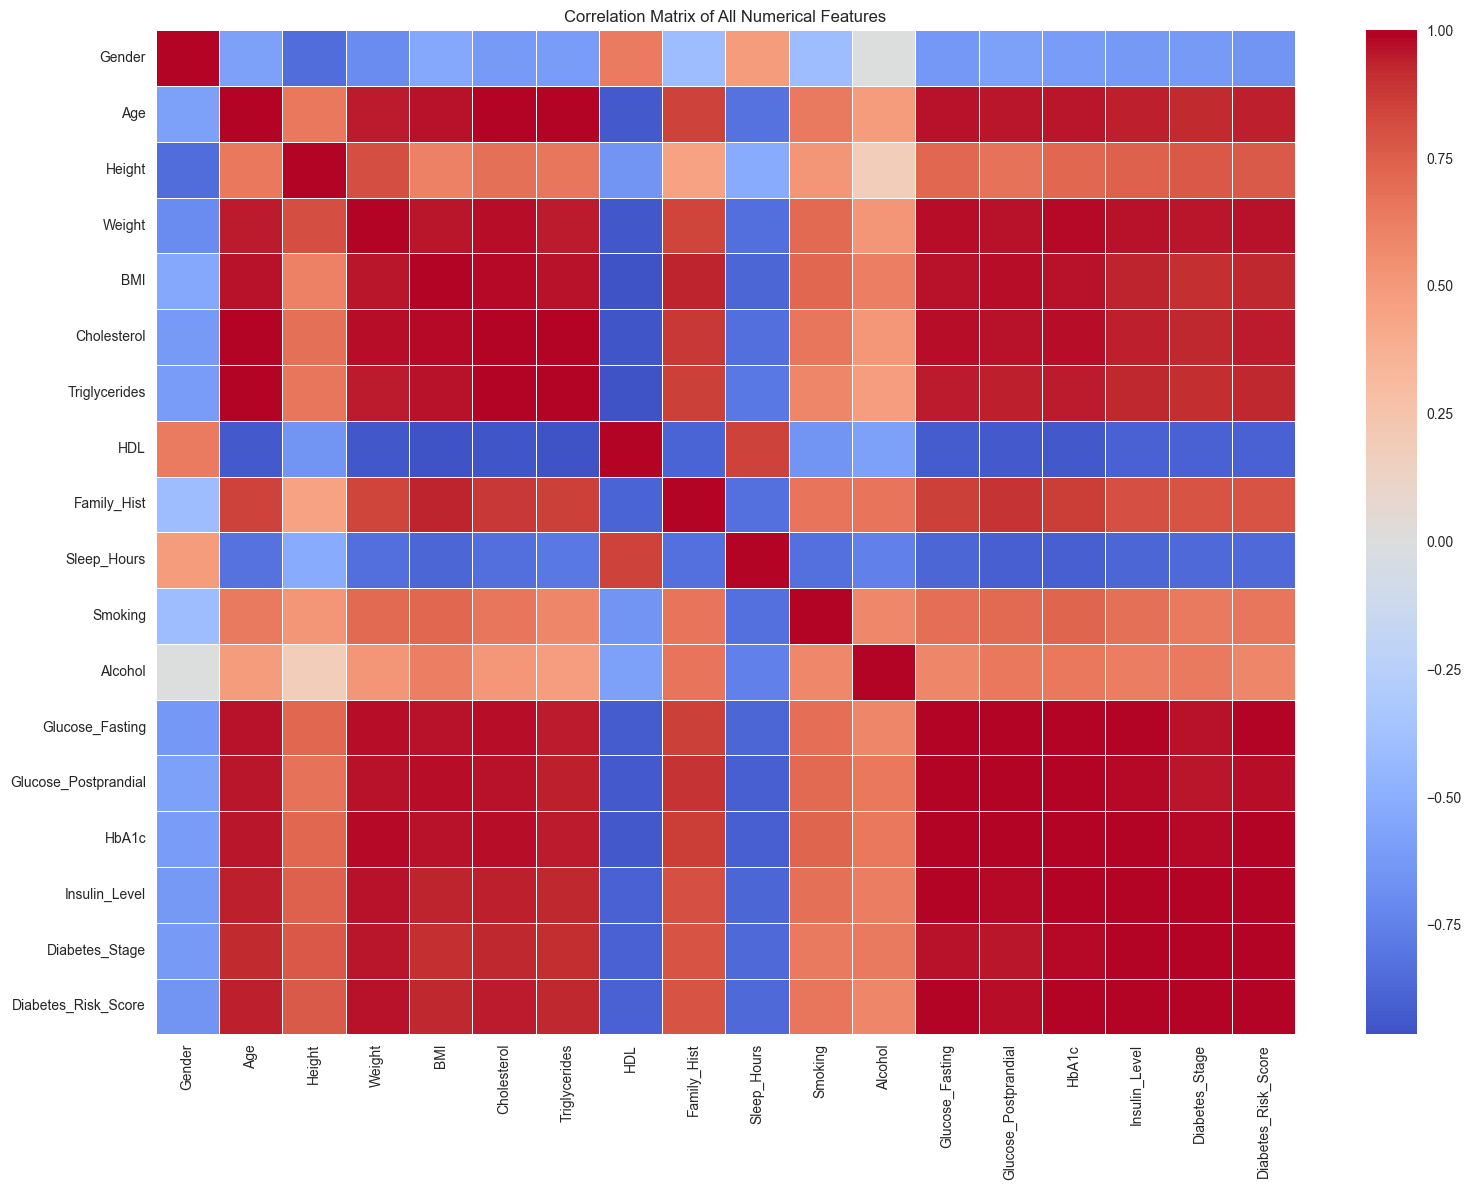

In [7]:
plt.figure(figsize=(16,12))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of All Numerical Features')
plt.tight_layout()
plt.show()

=== Average Values by Diabetes Stage ===
                  BMI  HbA1c  Glucose_Fasting  Diabetes_Risk_Score  \
Diabetes_Stage                                                       
0               22.52   5.05            91.25                 0.11   
1               29.13   6.53           116.67                 0.37   
2               31.10   7.20           130.00                 0.60   
3               32.40   8.25           145.00                 0.85   

                Physical_Activity  Sleep_Hours   Age  Weight  
Diabetes_Stage                                                
0                             NaN         8.25  29.5   58.75  
1                             NaN         6.50  45.0   76.67  
2                             NaN         7.00  60.0   90.00  
3                             NaN         5.25  60.0   97.50  


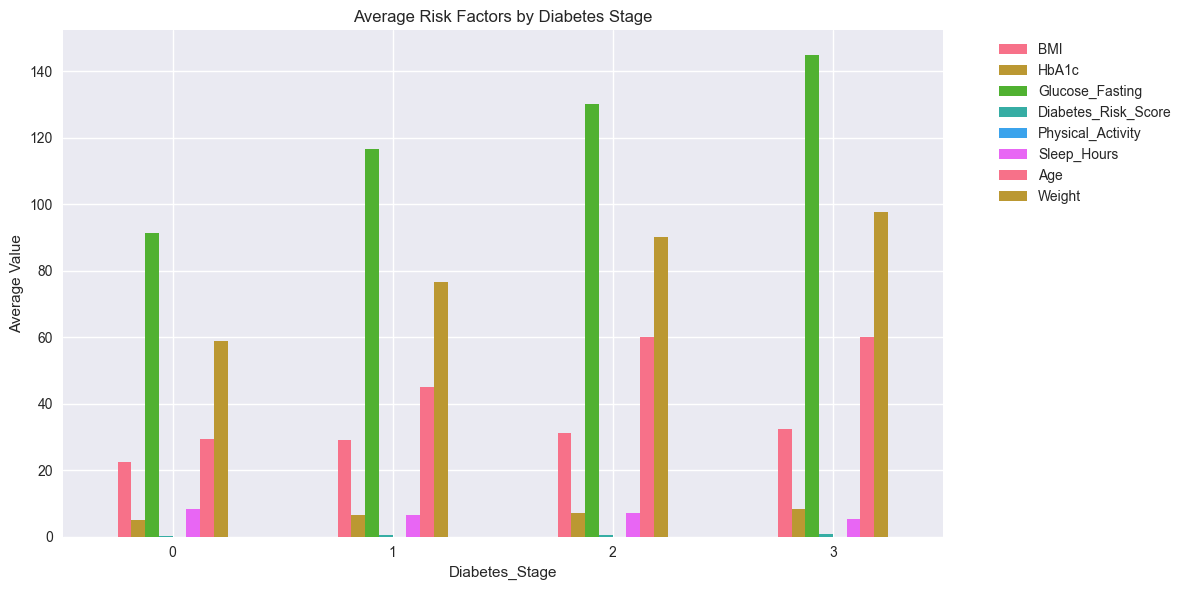

In [8]:
key_features = ['BMI', 'HbA1c', 'Glucose_Fasting', 'Diabetes_Risk_Score',
                'Physical_Activity', 'Sleep_Hours', 'Age', 'Weight']

for col in key_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("=== Average Values by Diabetes Stage ===")
print(df.groupby('Diabetes_Stage')[key_features].mean().round(2))

# Visualise
df.groupby('Diabetes_Stage')[key_features].mean().plot(kind='bar', figsize=(12,6))
plt.title('Average Risk Factors by Diabetes Stage')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

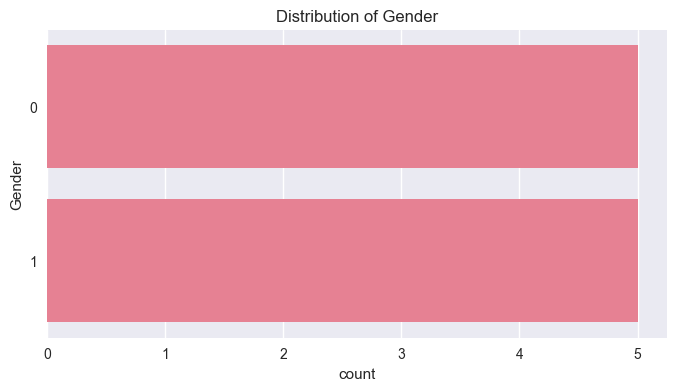

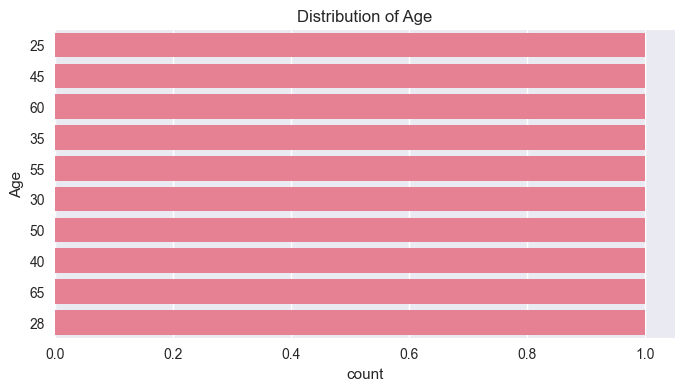

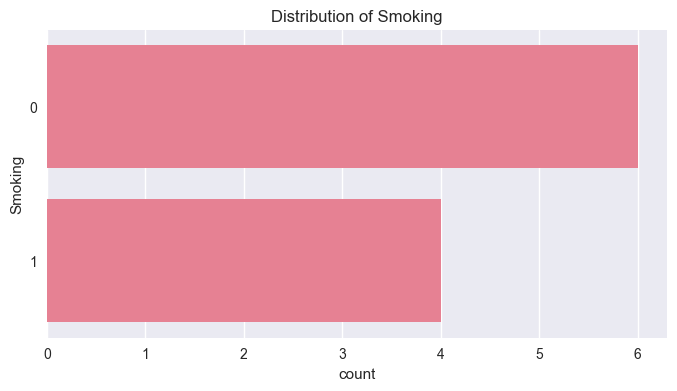

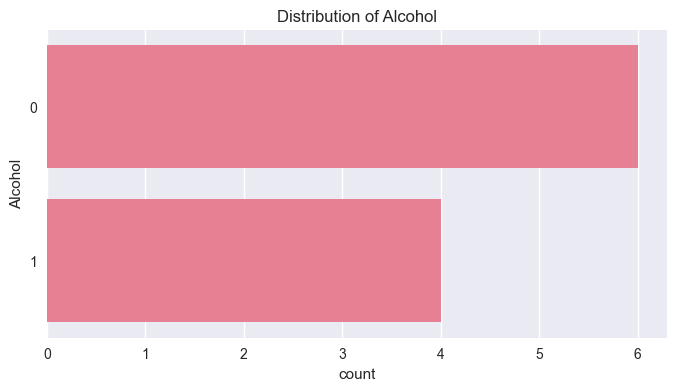

In [9]:
cat_cols = ['Gender', 'Age', 'Smoking', 'Alcohol']

for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(8,4))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.show()

## 3. Data Cleaning & Preprocessing

In [10]:
# Impute missing values
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Missing values handled!")
print("Remaining missing values:", df.isnull().sum().sum())

✅ Missing values handled!
Remaining missing values: 10


In [11]:
le = LabelEncoder()
df['Diabetes_Stage_encoded'] = le.fit_transform(df['Diabetes_Stage'])

print("Target Encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Target Encoding:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3)}


In [12]:
os.makedirs('../data', exist_ok=True)

df.to_csv('../data/cleaned_diabetes_data.csv', index=False)
print("✅ Cleaned dataset saved as '../data/cleaned_diabetes_data.csv'")
print(f"Final shape: {df.shape}")

✅ Cleaned dataset saved as '../data/cleaned_diabetes_data.csv'
Final shape: (10, 24)
